In [1]:
from forestkernel import LeafEncoder
from forestkernel.prediction.functional import kernel_predict
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor, ExtraTreesClassifier, ExtraTreesRegressor
from xgboost import XGBClassifier, XGBRegressor
from lightgbm import LGBMClassifier, LGBMRegressor
from sklearn.ensemble import GradientBoostingClassifier, GradientBoostingRegressor
from sklearn.model_selection import train_test_split
from pathlib import Path
import sys

PROJECT_ROOT = Path.cwd().resolve().parents[0]

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from dataset import dataprep


import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns


## Read in the data and normalize

In [2]:
# TODO: Test with NumPy and Pandas, ALL METHODS and perhaps combos of each type. Problem with categorical data in Pandas?
# We should probably modify RFGAP to handle categorical data in the form of strings.

In [3]:
seed = 42

forest_type = "rf"  # one of {"rf", "et", "xgb", "lgbm", "gbt"}

weight_scheme = "gap"

force_symmetric = False
adjust_diagonal = False


if forest_type == "rf":
    forest = RandomForestClassifier(
        max_samples=None,
        oob_score=True,
        bootstrap=True,
        n_estimators=100,
        verbose=1,
        n_jobs=-1,
        random_state=seed,
    )

elif forest_type == "et":
    forest = ExtraTreesClassifier(
        max_samples=None,
        oob_score=True,
        bootstrap=True,
        n_estimators=100,
        verbose=1,
        n_jobs=-1,
        random_state=seed,
    )

elif forest_type == "xgb":
    forest = XGBClassifier(
        n_estimators=100,
        random_state=seed,
        verbosity=0,
        n_jobs=-1,
    )

elif forest_type == "lgbm":
    forest = LGBMClassifier(
        n_estimators=100,
        random_state=seed,
        verbose=-1,
        n_jobs=-1,
    )

elif forest_type == "gbt":
    forest = GradientBoostingClassifier(
        n_estimators=100,
        random_state=seed,
        verbose=1,
    )

else:
    raise ValueError("forest_type must be one of {'rf', 'et', 'xgb', 'lgbm', 'gbt'}.")


test_size=0.2

# data = pd.read_parquet('/NOBACKUP/aumona/projects/RF-GAP-Python/data/sign_mnist_test.parquet')
# data = pd.read_parquet('/NOBACKUP/aumona/projects/RF-GAP-Python/data/tv_news_combined.parquet')
data = pd.read_csv('/Users/aumona/Projects/RF-GAP-Python/data/iris.csv')
# data = pd.read_parquet('/Users/aumona/Projects/RF-GAP-Python/data/sign_mnist_train.parquet')


print(data.dtypes)


x, y   = dataprep(data, scale='normalize', factorize_labels=False)

n_samples = x.shape[0]
n_features = x.shape[1]

x_train, x_test, y_train, y_test = train_test_split(x, y, test_size = test_size, random_state = seed)

print(f"Train samples: {x_train.shape[0]}, Test samples: {x_test.shape[0]}")
print(f"Number of features: {x_train.shape[1]}")
print(f"Unique classes: {np.unique(y_train)}")

species          object
sepal_length    float64
sepal_width     float64
petal_length    float64
petal_width     float64
dtype: object
Initial shape: (150, 5)
Missing labels handling: drop_missing_y=False, kept 0 row(s) with missing values in 'species'.
Label column: 'species'
Label handling: kept categorical/string labels as original values.
Number of unique values: 3
Categorical feature columns: none
Continuous numeric feature columns: ['sepal_length', 'sepal_width', 'petal_length', 'petal_width']
Binary / indicator feature columns: none
Feature handling: no categorical feature columns to one-hot encode.
Scaling: normalized continuous numeric feature columns to [0, 1].
Final feature shape: (150, 4)
Train samples: 120, Test samples: 30
Number of features: 4
Unique classes: ['setosa' 'versicolor' 'virginica']


## Train the RF Model

In [4]:
enc = LeafEncoder(
          weight_scheme = weight_scheme,
          forest=forest
           )
enc

,forest,"RandomForestC...42, verbose=1)"
,weight_scheme,'gap'
,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0


In [5]:
enc.fit(x_train, y_train)

[Parallel(n_jobs=-1)]: Using backend ThreadingBackend with 12 concurrent workers.
[Parallel(n_jobs=-1)]: Done  26 tasks      | elapsed:    0.0s
[Parallel(n_jobs=-1)]: Done 100 out of 100 | elapsed:    0.0s finished
[Parallel(n_jobs=-1)]: Using backend ThreadingBackend with 12 concurrent workers.
[Parallel(n_jobs=-1)]: Done  26 tasks      | elapsed:    0.0s
[Parallel(n_jobs=-1)]: Done 100 out of 100 | elapsed:    0.0s finished


,forest,"RandomForestC...42, verbose=1)"
,weight_scheme,'gap'
,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0


## Generate the Kernel Matrix

In [6]:
Q = enc.training_query_map()
print(Q.shape)
W = enc.reference_map()
print(W.shape)
print(enc.cache_.total_unique_nodes)

prox = enc.kernel(adjust_diagonal=adjust_diagonal, force_symmetric=force_symmetric)

(120, 1644)
(120, 1644)
1644


# Check kernel shape and %nnz

In [7]:
# NNZ
print(f"Proximity matrix shape: {prox.shape}, NNZ: {prox.nnz}, Density: {prox.nnz / (prox.shape[0] * prox.shape[1])}")

Proximity matrix shape: (120, 120), NNZ: 5330, Density: 0.3701388888888889


# Visualize it

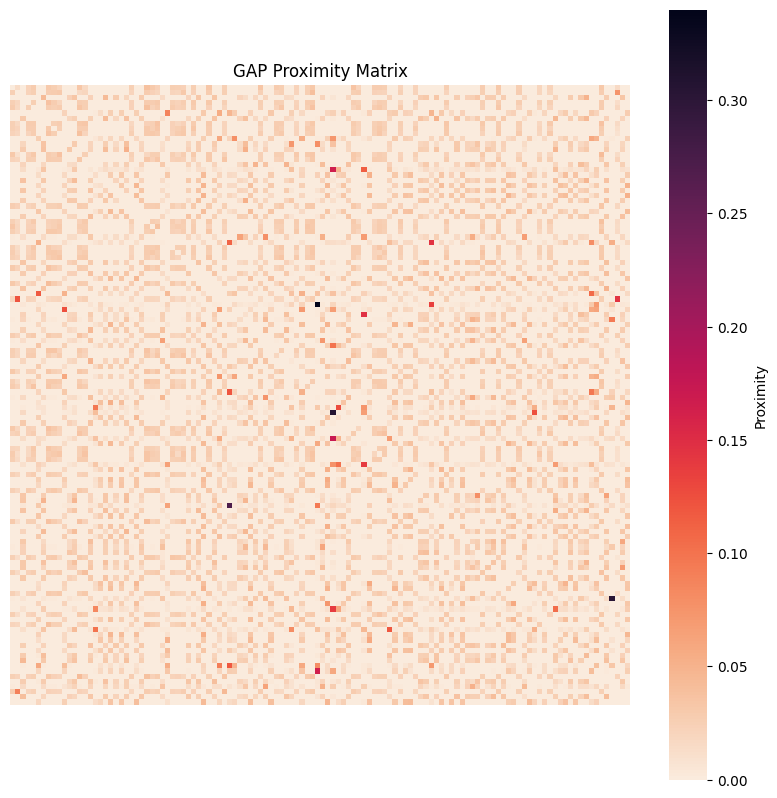

Row sums :
[1.         1.         1.0000001  1.         0.99999994 1.
 1.         1.         1.         1.         1.         1.
 1.         1.         1.         1.0000001  1.         1.0000001
 1.0000001  1.         1.         1.0000001  1.0000001  1.
 1.         1.         1.         1.0000001  1.         1.
 1.0000001  1.         1.         0.99999994 1.         1.
 1.         1.         0.9999999  1.         1.         1.
 1.         1.0000001  0.99999994 1.         1.         1.
 1.         1.         0.99999994 1.         0.99999994 0.99999994
 1.0000001  1.         1.         1.0000001  0.99999994 1.
 1.         1.         1.         1.         1.         1.
 1.         1.0000001  1.         0.99999994 0.99999994 1.0000001
 1.         1.         1.         1.0000001  1.         1.
 1.         1.         1.         1.         1.         1.
 1.         1.0000001  1.         1.         1.         1.
 1.         1.         1.         1.         0.99999994 1.
 1.         1.         

In [8]:
prox_mat = prox.toarray()

# mask diagonal to emphasize off-diagonal proximities
mask = np.eye(prox_mat.shape[0], dtype=bool)
mask=None

fig, ax = plt.subplots(figsize=(10, 10))
sns.heatmap(prox_mat, ax=ax, cmap='rocket_r', vmin=prox_mat.min(), vmax=prox_mat.max(),
            mask=mask,
            xticklabels=False, yticklabels=False, square=True, cbar_kws={'label': 'Proximity'})
ax.set_title(f'{weight_scheme.upper()} Proximity Matrix')
plt.show()

# Check row sums
row_sums = prox_mat.sum(axis=1)
print("Row sums :")
print(row_sums)

# Check column sums
col_sums = prox_mat.sum(axis=0)
print("Column sums :")
print(col_sums)

# Show diagonal values
diag = prox.diagonal()
print("Diagonal values:")
print(diag)

# Show max off diagonal value
off_diag_max = prox_mat - np.diag(diag)
print("Max off-diagonal value:")
print(off_diag_max.max())

## Check extended kernel computation using a training subset

[Parallel(n_jobs=-1)]: Using backend ThreadingBackend with 12 concurrent workers.
[Parallel(n_jobs=-1)]: Done  26 tasks      | elapsed:    0.0s
[Parallel(n_jobs=-1)]: Done 100 out of 100 | elapsed:    0.0s finished


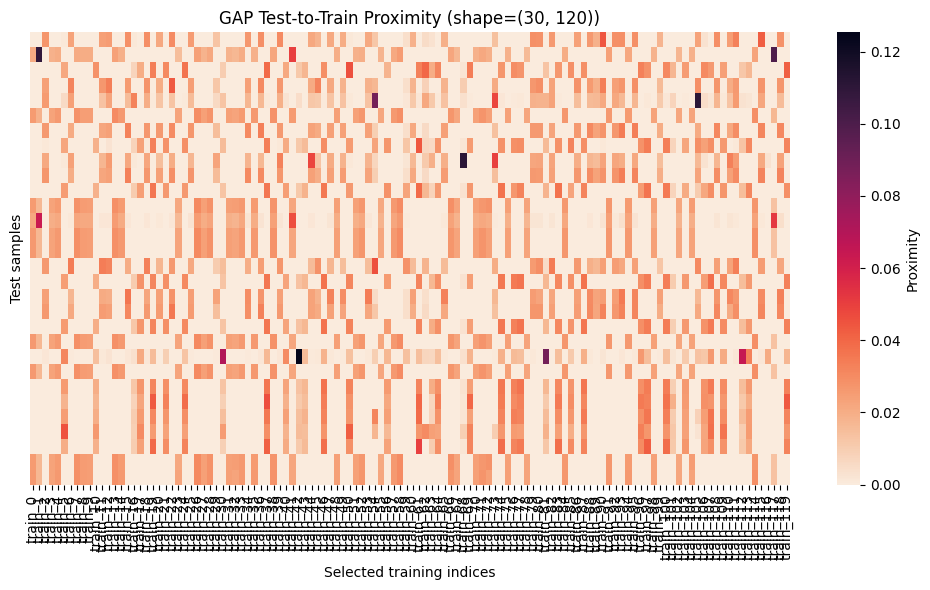

In [9]:
# selected_train_indices = [1,2,3,4,5,6,7,8,9,10,11,12,13,14,15]
selected_train_indices = np.arange(x_train.shape[0])
test_prox = enc.kernel_extend(x_test).toarray()
# test_prox = enc.kernel_extend(x_test).toarray()
fig, ax = plt.subplots(figsize=(10, 6))
sns.heatmap(test_prox, ax=ax, cmap='rocket_r', vmin=0, vmax=test_prox.max(),
            xticklabels=[f'train_{i}' for i in selected_train_indices],
            yticklabels=False, cbar_kws={'label': 'Proximity'})
ax.set_xlabel('Selected training indices')
ax.set_ylabel('Test samples')
ax.set_title(f'{weight_scheme.upper()} Test-to-Train Proximity (shape={test_prox.shape})')
plt.tight_layout()
plt.show()

## Check Sum-to-One

In [10]:
# Check train proximity row sums
prox_dense = prox.toarray() if hasattr(prox, "toarray") else np.asarray(prox)
row_sums = np.sum(prox_dense, axis=1)

print("TRAIN")
print("rows:", row_sums.shape[0])
print("min, max, mean:", row_sums.min(), row_sums.max(), row_sums.mean())

tol_r, tol_a = 1e-5, 1e-8
close_mask = np.isclose(row_sums, 1.0, rtol=tol_r, atol=tol_a)
print(f"rows ~1 within rtol={tol_r}, atol={tol_a}: {np.count_nonzero(close_mask)}/{len(row_sums)}")

bad_idx = np.where(~close_mask)[0]
if bad_idx.size:
    print("Example rows not summing to ~1 (index, sum):")
    for i in bad_idx[:10]:
        print(i, row_sums[i])
else:
    print("All rows sum approximately to 1.")


# Check test/OOS proximity row sums
test_prox_dense = (
    test_prox.toarray()
    if hasattr(test_prox, "toarray")
    else np.asarray(test_prox)
)
test_row_sums = np.sum(test_prox_dense, axis=1)

print("\nTEST / OOS")
print("rows:", test_row_sums.shape[0])
print("min, max, mean:", test_row_sums.min(), test_row_sums.max(), test_row_sums.mean())

test_close_mask = np.isclose(test_row_sums, 1.0, rtol=tol_r, atol=tol_a)
print(
    f"rows ~1 within rtol={tol_r}, atol={tol_a}: "
    f"{np.count_nonzero(test_close_mask)}/{len(test_row_sums)}"
)

test_bad_idx = np.where(~test_close_mask)[0]
if test_bad_idx.size:
    print("Example test rows not summing to ~1 (index, sum):")
    for i in test_bad_idx[:10]:
        print(i, test_row_sums[i])
else:
    print("All test rows sum approximately to 1.")

TRAIN
rows: 120
min, max, mean: 0.9999999 1.0000001 1.0
rows ~1 within rtol=1e-05, atol=1e-08: 120/120
All rows sum approximately to 1.

TEST / OOS
rows: 30
min, max, mean: 0.99999976 0.99999994 0.9999999
rows ~1 within rtol=1e-05, atol=1e-08: 30/30
All test rows sum approximately to 1.


# Check prox weighted predictions

In [11]:
test_pred = enc.predict(x_test)

[Parallel(n_jobs=-1)]: Using backend ThreadingBackend with 12 concurrent workers.
[Parallel(n_jobs=-1)]: Done  26 tasks      | elapsed:    0.0s
[Parallel(n_jobs=-1)]: Done 100 out of 100 | elapsed:    0.0s finished


In [12]:
forest_pred = enc.forest_.predict(x_test)

[Parallel(n_jobs=12)]: Using backend ThreadingBackend with 12 concurrent workers.
[Parallel(n_jobs=12)]: Done  26 tasks      | elapsed:    0.0s
[Parallel(n_jobs=12)]: Done 100 out of 100 | elapsed:    0.0s finished


In [13]:
disagree_mask = test_pred != forest_pred
print(f"Number of disagreements between kernel predictions and forest predictions: {np.sum(disagree_mask)} out of {len(y_test)}")

Number of disagreements between kernel predictions and forest predictions: 0 out of 30


# Compare with a manual debug using kernel_predict()

In [14]:
test_pred_manual = kernel_predict(Q=enc.transform(x_test), W=W, y_train=y_train,
                                  weight_scheme=weight_scheme,
                                  is_classifier=True, return_proba=False)

[Parallel(n_jobs=-1)]: Using backend ThreadingBackend with 12 concurrent workers.
[Parallel(n_jobs=-1)]: Done  26 tasks      | elapsed:    0.0s
[Parallel(n_jobs=-1)]: Done 100 out of 100 | elapsed:    0.0s finished


In [15]:
disagree_mask = test_pred != test_pred_manual
print(f"Number of disagreements between KernelClassifier predictions and manual kernel_predictions: {np.sum(disagree_mask)} out of {len(y_test)}")

Number of disagreements between KernelClassifier predictions and manual kernel_predictions: 0 out of 30


# Measures of Trust

### RF-ICE (Trust Scores)

In [16]:
ice_scores = enc.diagnostics.get_instance_classification_expectation()
print(enc.diagnostics.trust_auc)

0.9677703602313967


#### Accuracy Rejection Curve

Text(0.5, 1.0, 'Scatter Plot of Training Data with 1 - Trust Scores')

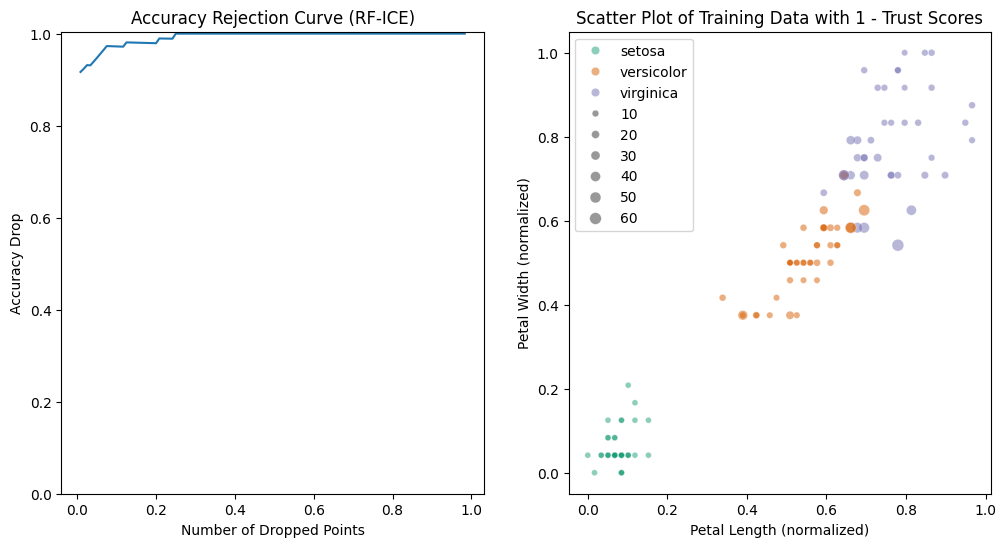

In [17]:
fig, ax = plt.subplots(1, 2, figsize=(12, 6))

sns.lineplot(x=enc.diagnostics.trust_n_drop, y=enc.diagnostics.trust_accuracy_drop, ax=ax[0])
ax[0].set_xlabel('Number of Dropped Points')
ax[0].set_ylabel('Accuracy Drop')
ax[0].set_title('Accuracy Rejection Curve (RF-ICE)')
ax[0].set_ylim(0, None)

sns.scatterplot(x=x_train[:, 2], y=x_train[:, 3], hue=y_train, palette='Dark2',
                size=(np.max(enc.diagnostics.trust_scores) - enc.diagnostics.trust_scores) * 100 + 5, alpha=0.5, ax=ax[1])
ax[1].set_xlabel('Petal Length (normalized)')
ax[1].set_ylabel('Petal Width (normalized)')
ax[1].set_title('Scatter Plot of Training Data with 1 - Trust Scores')


### RF-ICE for Test Set

In [18]:
trust_scores_test = enc.diagnostics.get_test_trust(x_test)

[Parallel(n_jobs=-1)]: Using backend ThreadingBackend with 12 concurrent workers.
[Parallel(n_jobs=-1)]: Done  26 tasks      | elapsed:    0.0s
[Parallel(n_jobs=-1)]: Done 100 out of 100 | elapsed:    0.0s finished


Text(0.5, 1.0, 'Test Data with 1 - Trust Scores')

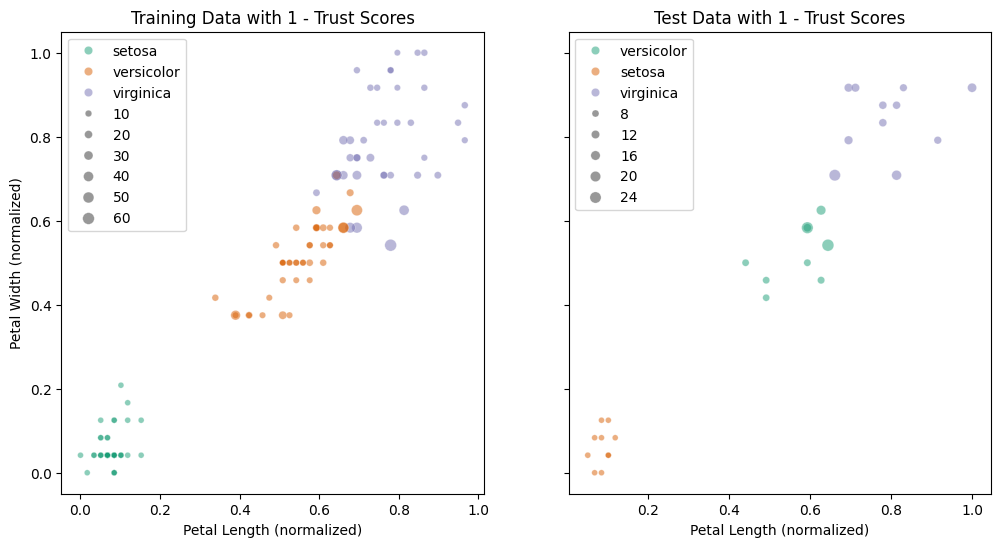

In [19]:
fig, ax = plt.subplots(1, 2, figsize=(12, 6), sharey = True)

sns.scatterplot(x=x_train[:, 2], y=x_train[:, 3], hue=y_train, palette='Dark2',
                size=(np.max(enc.diagnostics.trust_scores) - enc.diagnostics.trust_scores) * 100 + 5, alpha=0.5, ax=ax[0])
ax[0].set_xlabel('Petal Length (normalized)')
ax[0].set_ylabel('Petal Width (normalized)')
ax[0].set_title('Training Data with 1 - Trust Scores')

sns.scatterplot(x=x_test[:, 2], y=x_test[:, 3], hue=y_test, palette='Dark2',
                size=(np.max(enc.diagnostics.trust_scores_test) - enc.diagnostics.trust_scores_test) * 100 + 5, alpha=0.5, ax=ax[1])
ax[1].set_xlabel('Petal Length (normalized)')
ax[1].set_ylabel('Petal Width (normalized)')
ax[1].set_title('Test Data with 1 - Trust Scores')

In [20]:
enc.diagnostics.get_nonconformity(k = 5, X_test = x_test, weight_scheme = 'gap')

[Parallel(n_jobs=12)]: Using backend ThreadingBackend with 12 concurrent workers.
[Parallel(n_jobs=12)]: Done  26 tasks      | elapsed:    0.0s
[Parallel(n_jobs=12)]: Done 100 out of 100 | elapsed:    0.0s finished
[Parallel(n_jobs=-1)]: Using backend ThreadingBackend with 12 concurrent workers.
[Parallel(n_jobs=-1)]: Done  26 tasks      | elapsed:    0.0s
[Parallel(n_jobs=-1)]: Done 100 out of 100 | elapsed:    0.0s finished


array([ 0.        ,  0.        ,  0.        ,  0.        ,  0.        ,
        0.27208186,  0.        ,  0.        ,  0.        ,  0.        ,
        0.26796727,  0.        ,  0.        ,  0.        ,  0.        ,
        0.        ,  1.38704374,  0.1139865 ,  0.        ,  0.        ,
        0.        ,  0.        ,  0.        ,  0.        ,  0.        ,
        0.        ,  0.        ,  0.        ,  0.        ,  0.23445408,
        0.15478621,  0.        ,  0.        ,  0.        ,  0.        ,
        0.        ,  0.        ,  0.        ,  0.        ,  0.        ,
        0.30209735,  0.        ,  1.3944562 ,  0.19480857,  0.88690067,
        0.54343701,  0.        ,  0.        ,  0.        ,  0.03795745,
        0.56622755,  0.        ,  0.        ,  0.        ,  6.51987723,
        0.        ,  0.        ,  0.        ,  0.        , 11.04363251,
        0.14980276,  0.15442878,  4.26090196,  1.56190948,  0.        ,
        0.        ,  0.        ,  0.        ,  1.92162026,  0.25

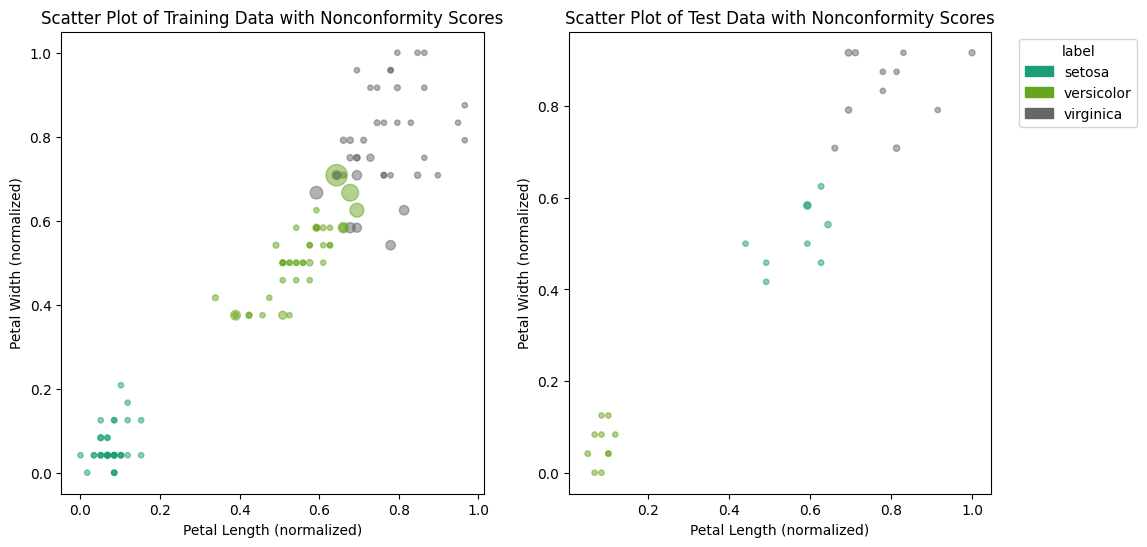

In [21]:
fig, ax = plt.subplots(1, 2, figsize=(12, 6))

sizes_train = enc.diagnostics.nonconformity_scores * 20 + 15
sizes_test = enc.diagnostics.nonconformity_scores_test * 20 + 15

labels_train_idx, labels_train_uniques = pd.factorize(np.asarray(y_train))
labels_test_idx, labels_test_uniques = pd.factorize(np.asarray(y_test))

ax[0].scatter(x_train[:, 2], x_train[:, 3], c=labels_train_idx, cmap='Dark2',
            s=sizes_train, alpha=0.5)
ax[0].set_xlabel('Petal Length (normalized)')
ax[0].set_ylabel('Petal Width (normalized)')
ax[0].set_title('Scatter Plot of Training Data with Nonconformity Scores')

ax[1].scatter(x_test[:, 2], x_test[:, 3], c=labels_test_idx, cmap='Dark2',
            s=sizes_test, alpha=0.5)
ax[1].set_xlabel('Petal Length (normalized)')
ax[1].set_ylabel('Petal Width (normalized)')
ax[1].set_title('Scatter Plot of Test Data with Nonconformity Scores')

# map factorized colors back to labels (compact)
cmap = plt.colormaps['Dark2']
handles = [mpatches.Patch(color=cmap(i / max(1, len(labels_train_uniques)-1)), label=l) for i, l in enumerate(labels_train_uniques)]
ax[1].legend(handles=handles, title='label', bbox_to_anchor=(1.05, 1), loc='upper left')

Text(0.5, 1.0, 'Conformity Accuracy Rejection Curve')

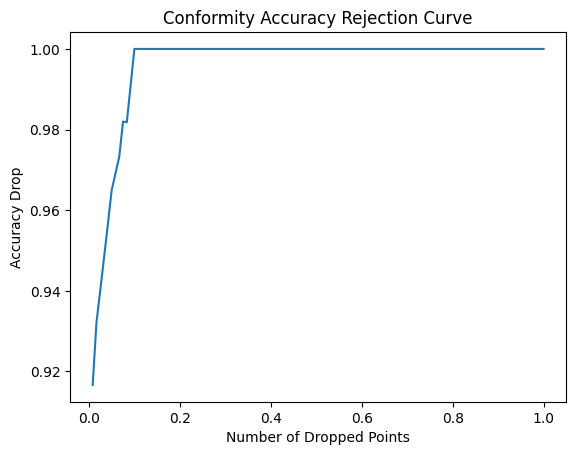

In [22]:
sns.lineplot(x=enc.diagnostics.conformity_n_drop, y=enc.diagnostics.conformity_accuracy_drop)
plt.xlabel('Number of Dropped Points')
plt.ylabel('Accuracy Drop')
plt.title('Conformity Accuracy Rejection Curve')

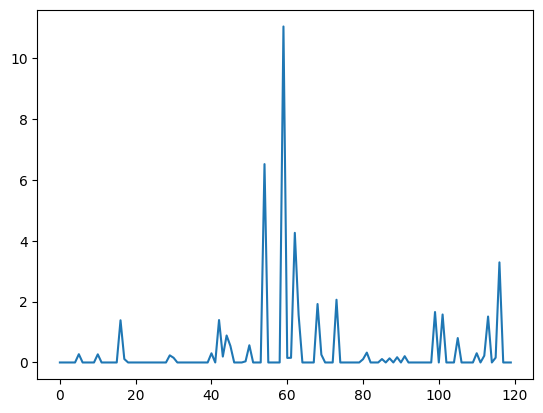

In [23]:
plt.plot(enc.diagnostics.nonconformity_scores)

In [24]:
                # Updates the following attributes:
                # - `self.nonconformity_scores`
                # - `self.conformity_scores`
                # - `self.conformity_quantiles`
                # - `self.conformity_auc`
                # - `self.conformity_accuracy_drop`
                # - `self.conformity_n_drop`
                
                # If `x_test` is provided, also updates:
                # - `self.nonconformity_scores_test`
                # - `self.conformity_scores_test`
                # - `self.conformity_quantiles_test`